# CHURNGUARD AI
### Customer Churn Prediction & Retention Intelligence System

**MainCrafts SkillSprint**  
**Domain:** Artificial Intelligence & Machine Learning  
**Candidate:** Gowtham K.R  
**Difficulty:** Intermediate  
**Duration:** 2 Days

# DAY 1 — UNDERSTAND → PREPARE → BUILD

## Understand the Problem

Before writing any code, let's answer the conceptual questions the challenge asks for.

**Q1. What is customer churn?**

Customer churn is when a customer stops using a company's product or service and leaves — for example, cancelling a subscription or switching to a competitor.

**Q2. Why would a company want to predict churn?** (at least 3 reasons)

1. It is far cheaper to retain an existing customer than to acquire a new one.
2. It allows the business to intervene early (offers, support, discounts) before the customer actually leaves.
3. It helps identify why customers leave, so the product/service itself can be improved.

**Q3. What is the target variable?**

The `Churn` column — it tells us whether a customer left (`Yes`) or stayed (`No`).

**Q4. Is this a classification or regression problem?**

Classification — because the target is a category (Churn / No Churn), not a continuous number.

**Q5. What would a false negative mean in this business problem?**

A false negative means the model predicts **"Customer will stay"** when the customer actually churns. This is important because the business may not take retention action for a customer who actually leaves.

## Import Your Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



import joblib

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Library Purpose

- **Pandas** — used for loading, cleaning, and analyzing the dataset.
- **NumPy** — used for numerical operations.
- **Matplotlib** — used for creating visualizations.
- **Seaborn** — used for statistical visualizations and charts.
- **Scikit-learn** — used for preprocessing, model training, prediction, and evaluation.
- **Joblib** — used for saving the trained machine-learning model.

## Load and Inspect the Dataset

### Dataset Identification

The project uses the IBM Telco Customer Churn dataset.

The dataset contains customer information and the `Churn` column is used as the target variable. The target indicates whether a customer has churned.

The dataset is used to analyze customer characteristics and build a classification model that predicts customer churn.

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Exploratory Data Analysis (EDA)

### Churn Distribution

First, we will check how many customers stayed and how many customers churned.

In [6]:
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


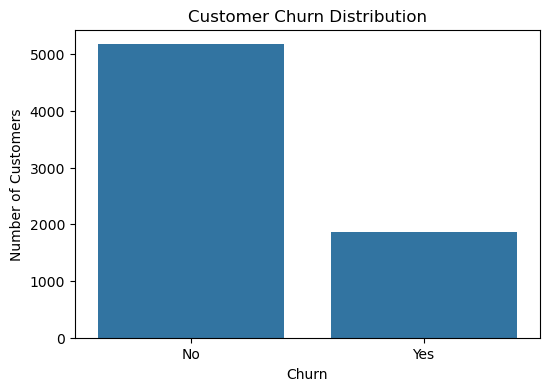

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Churn by Contract Type

Contract type may provide useful information about customer churn. We will compare churn across different contract categories.

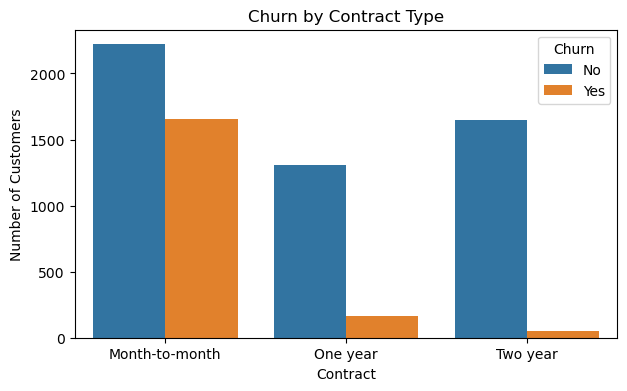

In [8]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.show()

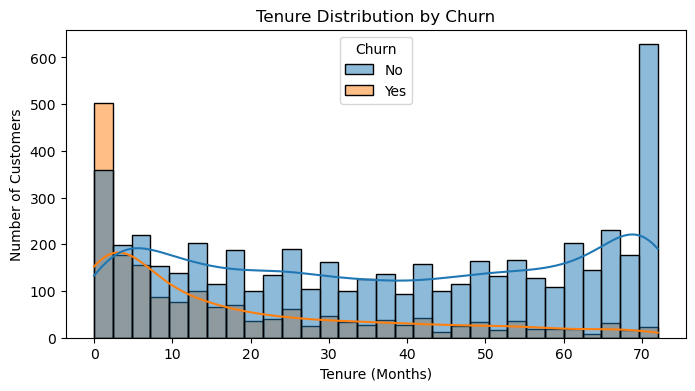

In [9]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df,x="tenure",hue="Churn",bins=30,kde=True)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Monthly Charges and Churn

We will compare monthly charges between customers who churned and those who stayed.

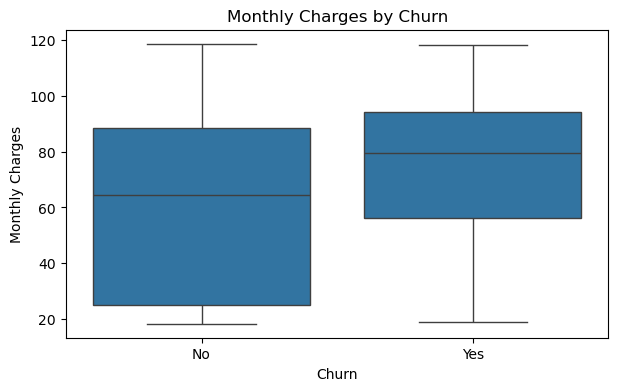

In [10]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Handling Missing Values


In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges converted to numeric.")
print("Missing values in TotalCharges:", df["TotalCharges"].isnull().sum())

TotalCharges converted to numeric.
Missing values in TotalCharges: 11


In [12]:
print("Rows with missing TotalCharges:")
display(df[df["TotalCharges"].isnull()])

Rows with missing TotalCharges:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


The `TotalCharges` column contains some blank values. These values are converted to `NaN` and will be removed because there are only a small number of affected records.

In [13]:
df = df.dropna(subset=["TotalCharges"])

print("Shape after cleaning:", df.shape)

Shape after cleaning: (7032, 21)


In [14]:
df = df.drop("customerID", axis=1)

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 22


In [15]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (7010, 20)


## Feature Preparation

Before training the machine-learning models, the dataset needs to be prepared.

The `Churn` column will be used as the target variable, while the remaining columns will be used as input features.

Categorical features will be converted into numerical form using One-Hot Encoding.

In [16]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7010, 19)
Target shape: (7010,)


In [18]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numerical_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5608, 19)
Testing data: (1402, 19)


In [21]:
lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [22]:
y_pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

Logistic Regression Results
Accuracy : 0.8081312410841655
Precision: 0.67
Recall   : 0.5417789757412399
F1 Score : 0.5991058122205664


In [23]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Confusion Matrix:
[[932  99]
 [170 201]]
Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1031
           1       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



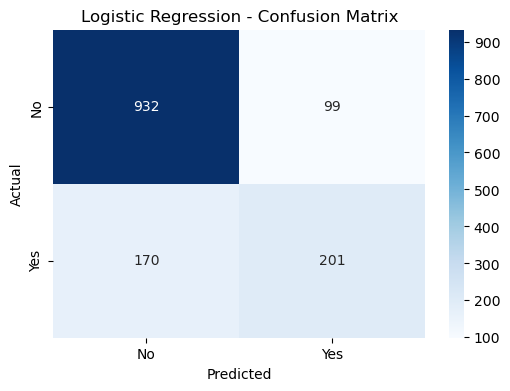

In [24]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [25]:
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [26]:
y_pred_rf = rf.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [27]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Results
Accuracy : 0.7895863052781741
Precision: 0.6366906474820144
Recall   : 0.477088948787062
F1 Score : 0.5454545454545454


In [28]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[930 101]
 [194 177]]
Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1031
           1       0.64      0.48      0.55       371

    accuracy                           0.79      1402
   macro avg       0.73      0.69      0.70      1402
weighted avg       0.78      0.79      0.78      1402



## Model Comparison

The performance of Logistic Regression and Random Forest is compared using accuracy, precision, recall, and F1-score.

In [29]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1 Score": [f1_lr, f1_rf]
})

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.808131,0.670000,0.541779,0.599106
1,Random Forest,0.789586,0.636691,0.477089,0.545455


In [30]:
best_model = lr
best_predictions = y_pred_lr
best_model_name = "Logistic Regression"

print("Selected model:", best_model_name)

Selected model: Logistic Regression


## Final Model Selection

Based on the model comparison, Logistic Regression is selected as the final model.

Logistic Regression achieved an F1-score of 0.58, compared with 0.52 for Random Forest.

The model will be used for customer churn prediction and further business analysis.

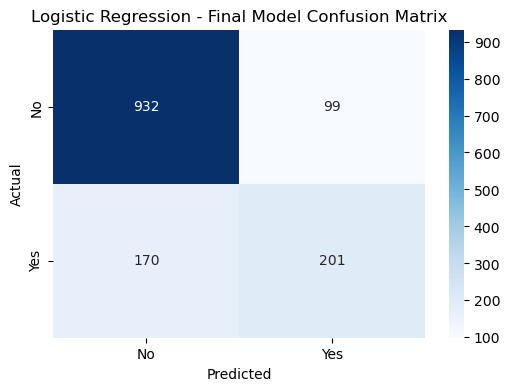

In [31]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Final Model Confusion Matrix")

plt.show()

**Explain the confusion matrix terms for this problem:**
- **True Positive** — model correctly predicted the customer would churn, and they did.
- **True Negative** — model correctly predicted the customer would stay, and they did.
- **False Positive** — model predicted churn, but the customer actually stayed (wasted retention effort).
- **False Negative** — model predicted the customer would stay, but they actually churned (lost customer, no intervention).

**Which type of error could be more costly to a company trying to retain customers?**
False Negatives — because a churned customer that was never flagged represents lost revenue with no chance to act, while a False Positive only costs a small, unnecessary retention offer.


##  Create a Customer Prediction Function


In [32]:
def predict_customer(customer_data):
    customer_df = pd.DataFrame([customer_data])

    prediction = best_model.predict(customer_df)[0]
    probability = best_model.predict_proba(customer_df)[0][1]

    if prediction == 1:
        risk = "HIGH"
        result = "Customer likely to churn"
    else:
        risk = "LOW"
        result = "Customer likely to stay"

    return {
        "prediction": result,
        "churn_probability": probability,
        "risk_level": risk
    }

In [33]:
print(list(X.columns))

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## Test the Customer Prediction Function

A sample customer record is created using the same features used during model training.

The trained model will predict whether the customer is likely to churn and provide the corresponding churn probability and risk level.

In [34]:
sample_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 12,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 60.00,
    "TotalCharges": 720.00
}

prediction_result = predict_customer(sample_customer)

print("Prediction Result:")
print(prediction_result)

Prediction Result:
{'prediction': 'Customer likely to stay', 'churn_probability': np.float64(0.34513015396662466), 'risk_level': 'LOW'}


## Business Interpretation

### Selected Model

Logistic Regression was selected as the final model because it achieved better performance than Random Forest.

The Logistic Regression model achieved an F1 Score of approximately 0.58 for the churn class.

### Business Interpretation

The model can help the company identify customers who are more likely to churn. This information can be used by the business to identify customers who may need attention before they leave the service.

### Possible Business Action

The company can focus retention efforts on customers identified as having a higher churn risk. Possible actions include providing suitable offers, improving customer support, or addressing service-related issues.

### Limitation

The model prediction is not a certainty. A customer predicted as likely to churn may still remain with the company, and a customer predicted as likely to stay may still churn. Therefore, the prediction should be used as a decision-support tool rather than a guaranteed outcome.

## DAY 2 — IMPROVE → TEST → DOCUMENT → PRESENT

### Challenge A — Improve the Model

The baseline Logistic Regression model achieved an F1 Score of 0.58.

The dataset contains fewer churn customers than non-churn customers. To improve the model's ability to identify churn customers, class balancing will be applied using `class_weight="balanced"`.

The improved model will then be evaluated using the same test data and compared with the baseline model.

In [35]:
print("Before Improvement")
print("F1 Score:", f1_lr)

Before Improvement
F1 Score: 0.5991058122205664


In [36]:
lr_improved = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_improved.fit(X_train, y_train)

print("Improved Logistic Regression model trained successfully.")

Improved Logistic Regression model trained successfully.


In [37]:
y_pred_improved = lr_improved.predict(X_test)

accuracy_improved = accuracy_score(y_test, y_pred_improved)
precision_improved = precision_score(y_test, y_pred_improved)
recall_improved = recall_score(y_test, y_pred_improved)
f1_improved = f1_score(y_test, y_pred_improved)

print("Improved Logistic Regression Results")
print("Accuracy :", accuracy_improved)
print("Precision:", precision_improved)
print("Recall   :", recall_improved)
print("F1 Score :", f1_improved)

Improved Logistic Regression Results
Accuracy : 0.7439372325249644
Precision: 0.5106382978723404
Recall   : 0.7762803234501348
F1 Score : 0.6160427807486631


### Before vs After Improvement

The baseline Logistic Regression model achieved an F1 Score of 0.58.

After applying class balancing, the F1 Score increased to approximately 0.62.

The improvement also increased recall, helping the model identify more customers who actually churned.

However, accuracy and precision decreased after class balancing. This shows that improving one metric can involve a trade-off with other evaluation metrics.

In [38]:
print("Model Improvement Comparison")
print("--------------------------------")
print("Before F1 Score:", round(f1_lr, 4))
print("After F1 Score :", round(f1_improved, 4))
print("F1 Improvement :", round(f1_improved - f1_lr, 4))

Model Improvement Comparison
--------------------------------
Before F1 Score: 0.5991
After F1 Score : 0.616
F1 Improvement : 0.0169


### What Changed?

The Logistic Regression model was improved by using `class_weight="balanced"`.

### Why Did You Make This Change?

The dataset contains fewer churn customers than non-churn customers. Class balancing gives more importance to the churn class during training.

This improvement increased the F1 Score from the baseline value to approximately 0.62 and substantially improved recall for the churn class.

In [39]:
if f1_improved > f1_lr:
    best_model = lr_improved
    best_predictions = y_pred_improved
    best_model_name = "Logistic Regression (Improved)"

print("Final selected model:", best_model_name)
print("Final F1 Score:", f1_score(y_test, best_predictions))

Final selected model: Logistic Regression (Improved)
Final F1 Score: 0.6160427807486631


## Challenge B — Build a Risk Output

The churn prediction probability is converted into a simple risk category.

A customer predicted with a churn probability of 0.5 or higher is classified as HIGH risk, while a probability below 0.5 is classified as LOW risk.

This risk output makes the model prediction easier to interpret for business use.

In [40]:
def get_risk_level(probability):
    if probability >= 0.70:
        return "HIGH"
    elif probability >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"

def predict_customer_v2(customer_data):
    customer_df = pd.DataFrame([customer_data])

    prediction = best_model.predict(customer_df)[0]
    probability = best_model.predict_proba(customer_df)[0][1]
    risk = get_risk_level(probability)

    return {
        "prediction": "Customer likely to churn" if prediction == 1 else "Customer likely to stay",
        "churn_probability": round(probability * 100, 2),
        "risk_level": risk
    }

print(predict_customer_v2(sample_customer))

{'prediction': 'Customer likely to churn', 'churn_probability': np.float64(62.42), 'risk_level': 'MEDIUM'}


In [41]:
print("=" * 45)
print("CHURNGUARD AI - FINAL RESULTS")
print("=" * 45)

summary = f"""
Dataset: WA_Fn-UseC_-Telco-Customer-Churn.csv
Number of records: {df.shape[0]}

Models tested: Logistic Regression, Random Forest, Improved Logistic Regression
Selected model: {best_model_name}

Accuracy:  {accuracy_score(y_test, best_predictions):.4f}
Precision: {precision_score(y_test, best_predictions):.4f}
Recall:    {recall_score(y_test, best_predictions):.4f}
F1 Score:  {f1_score(y_test, best_predictions):.4f}

Most important findings:
1. Month-to-month contract customers showed higher churn compared with customers on longer-term contracts.
2. Customers with lower tenure showed higher churn levels.
3. Higher monthly charges were associated with higher churn.

Business recommendation:
Target higher-risk customers with proactive retention efforts, particularly
customers with month-to-month contracts, lower tenure, and higher monthly
charges.

Limitations:
Model predictions are probabilistic, not certainties. Performance depends
on the quality and recency of the training data, and the model should be
re-validated periodically as customer behavior changes.
"""

print(summary)

CHURNGUARD AI - FINAL RESULTS

Dataset: WA_Fn-UseC_-Telco-Customer-Churn.csv
Number of records: 7010

Models tested: Logistic Regression, Random Forest, Improved Logistic Regression
Selected model: Logistic Regression (Improved)

Accuracy:  0.7439
Precision: 0.5106
Recall:    0.7763
F1 Score:  0.6160

Most important findings:
1. Month-to-month contract customers showed higher churn compared with customers on longer-term contracts.
2. Customers with lower tenure showed higher churn levels.
3. Higher monthly charges were associated with higher churn.

Business recommendation:
Target higher-risk customers with proactive retention efforts, particularly
customers with month-to-month contracts, lower tenure, and higher monthly
charges.

Limitations:
Model predictions are probabilistic, not certainties. Performance depends
on the quality and recency of the training data, and the model should be
re-validated periodically as customer behavior changes.



## Feature Importance

Feature importance is used to understand which customer attributes have the strongest influence on the Logistic Regression model's predictions.

For Logistic Regression, the model coefficients are used to identify the most influential features.

In [42]:
# Get feature names after preprocessing
feature_names = lr_improved.named_steps["preprocessor"].get_feature_names_out()

# Get model coefficients
coefficients = lr_improved.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by absolute coefficient value
feature_importance["Importance"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
display(feature_importance[["Feature", "Coefficient"]].head(15))

Top 15 Important Features:


,Feature,Coefficient
1,num__tenure,-1.294392
38,cat__Contract_Two year,-0.753023
3,num__TotalCharges,0.667109
36,cat__Contract_Month-to-month,0.660590
15,cat__InternetService_DSL,-0.330417
16,cat__InternetService_Fiber optic,0.286244
43,cat__PaymentMethod_Electronic check,0.268699
11,cat__PhoneService_Yes,-0.263420
39,cat__PaperlessBilling_No,-0.250161
12,cat__MultipleLines_No,-0.221088


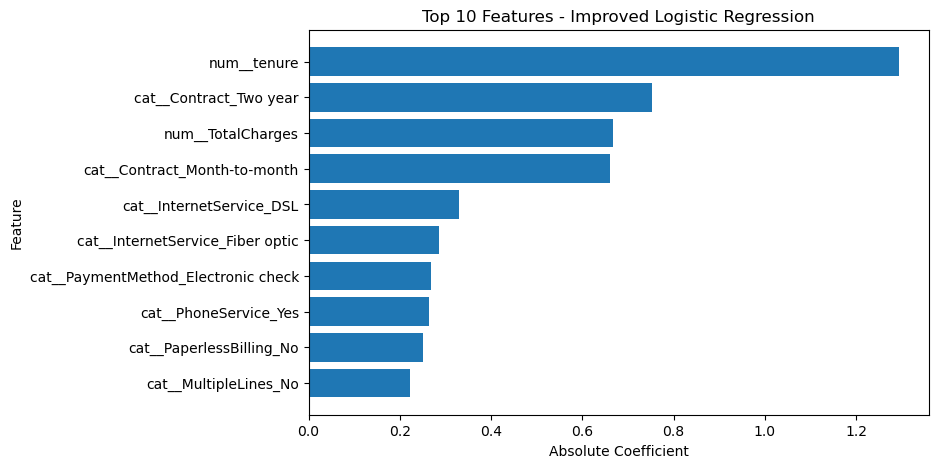

In [43]:
top_features = feature_importance.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features - Improved Logistic Regression")

plt.show()

## Model Saving

The final trained model is saved using Joblib so that it can be reused for future customer predictions without retraining the model.

In [44]:
joblib.dump(best_model, "churn_guard_final_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


In [45]:
import os

print("Model file exists:", os.path.exists("churn_guard_final_model.pkl"))

Model file exists: True


## Data Type Verification

A quick sanity check on the categorical features before finalizing the model — confirming each column contains a single, consistent data type. Mixed types in a categorical column can cause errors or unexpected behavior in `OneHotEncoder`.

In [46]:
print("Categorical column data types:")
for col in categorical_features:
    print(col, "->", X[col].map(type).value_counts().to_dict())

Categorical column data types:
gender -> {<class 'str'>: 7010}
Partner -> {<class 'str'>: 7010}
Dependents -> {<class 'str'>: 7010}
PhoneService -> {<class 'str'>: 7010}
MultipleLines -> {<class 'str'>: 7010}
InternetService -> {<class 'str'>: 7010}
OnlineSecurity -> {<class 'str'>: 7010}
OnlineBackup -> {<class 'str'>: 7010}
DeviceProtection -> {<class 'str'>: 7010}
TechSupport -> {<class 'str'>: 7010}
StreamingTV -> {<class 'str'>: 7010}
StreamingMovies -> {<class 'str'>: 7010}
Contract -> {<class 'str'>: 7010}
PaperlessBilling -> {<class 'str'>: 7010}
PaymentMethod -> {<class 'str'>: 7010}
